# Header

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cmdstanpy
import arviz as az

import boto3
from configparser import ConfigParser
import awswrangler as wr

In [2]:
n_chains = 4
iter_warmup = 1000
iter_sampling = 1000

In [3]:
config = ConfigParser()
config.read(r'C:\Users\RyanKarel\.aws\credentials')

boto3_session = boto3.session.Session(
    aws_access_key_id=config['218527194748_ActuaryAccessProd']['aws_access_key_id'],
    aws_secret_access_key=config['218527194748_ActuaryAccessProd']['aws_secret_access_key'],
    aws_session_token=config['218527194748_ActuaryAccessProd']['aws_session_token'],
    region_name='us-east-1',
)

def query_athena(
    sql: str,
    boto3_session,
    database: str = "rn_actuary_db",
    workgroup: str = "Actuary",
    index_col = None,
    check_index_uniqueness: bool = True,
    force_index_uniqueness: bool = False,
) -> pd.DataFrame:
    output = wr.athena.read_sql_query(
        sql=sql,
        database=database,
        boto3_session=boto3_session,
        workgroup=workgroup,
        ctas_approach=False,
    )
    if index_col is not None:
        if force_index_uniqueness:
            output.drop_duplicates(subset=index_col, inplace=True)
        output.set_index(index_col, inplace=True)
        if check_index_uniqueness:
            assert output.index.is_unique
    return output

def factor_lump(s: pd.Series, options: list, other_string: str = 'Other') -> pd.Series:
    return np.where(
        s.isin(options),
        s,
        other_string
    )

## Group Categorizations

Specify which class groups, states, and products should have their own distinct groupings.

### Class Groups

In [4]:
allowed_classes_sql = """
with tmp as (
    select
        substr(cd_product, -2) as cd_product,
        coalesce(lcg.cd_group_name, 'Other') cd_largest_class_group,
        count(*) as n
    from tbl_policy p
    left join vw_largest_class_group lcg using (num_policy)
    where
        coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
        and p.cd_product not in ('CP', 'IM') -- non property
    group by 1, 2
    having count(*) > 10
    order by 1, 3 desc
),
enumerated as (
    select
        *,
        row_number() over (partition by cd_product order by n desc) as rn
    from tmp
)

select distinct cd_largest_class_group
from enumerated
where rn <= 10
and cd_largest_class_group != 'Other'
and n > 100
order by 1
"""

cd_class_groups = query_athena(allowed_classes_sql, boto3_session)['cd_largest_class_group'].to_list()
cd_class_groups

['Apartments',
 'Assisted Living Facility',
 'Carpentry',
 'Concrete',
 'Condominiums',
 'Daycares',
 'Digging',
 'Exec Supervisors',
 'Generic Premises',
 'HVAC',
 'Home Health Agency',
 'Hotels and Motels',
 'Insurance Agents',
 'Intermediate Care / Group Home',
 'Lawyers',
 'Manufacturing or Processing',
 'Mercantile',
 'Miscellaneous Professional',
 'Painting',
 'Plumbing',
 'Police Professional',
 'Public Officials',
 'Restaurants and Clubs',
 'Roofing',
 'School Boards',
 'Subcontracting',
 'Townhouses',
 'Youth Residential']

### States / Venues

In [5]:
state_sql = """
with tmp as (
    select
        substr(cd_product, -2) as cd_product,
        cd_primary_risk_state,
        count(*) as n
    from tbl_policy p
    where
        coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
        and p.cd_product not in ('CP', 'IM') -- non property
    group by 1, 2
    having count(*) > 10
    order by 1, 3 desc
),
enumerated as (
    select
        *,
        row_number() over (partition by cd_product order by n desc) as rn
    from tmp
)

select distinct cd_primary_risk_state
from enumerated
where rn <= 5
and n > 100
order by 1
"""

cd_states = query_athena(state_sql, boto3_session)['cd_primary_risk_state'].to_list()

cd_states

['AZ', 'CA', 'CO', 'FL', 'GA', 'NJ', 'NY', 'PA', 'TX', 'WA']

### Causes of Loss

In [6]:
cause_sql = """
with tmp as (
    select
        substr(p.cd_product, -2) as cd_product,
        cd_cause_of_loss,
        count(*) as n
    from tbl_claim c
    inner join tbl_policy p using (num_policy)
    where
        coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
        and p.cd_product not in ('CP', 'IM') -- non property
    group by 1, 2
    having count(*) > 10
    order by 3 desc
),
enumerated as (
    select
        *,
        row_number() over (partition by cd_product order by n desc) as rn
    from tmp
    where cd_cause_of_loss != 'Other'
)

select distinct cd_cause_of_loss
from enumerated
where
rn <= 10
and n > 10
"""

cd_cause_of_loss = query_athena(cause_sql, boto3_session)['cd_cause_of_loss'].to_list()

cd_cause_of_loss

['Discrimination-Employment-ADA',
 'Failure to protect',
 'Discrimination-Racial',
 'Discrimination-ADA',
 'Contractual',
 'Fall - not in bathroom/shower',
 'Decubitus ulcer',
 'Loading or unloading',
 'Wrongful termination',
 'Violation of Civil Rights - 1st and/or 14th Amendment',
 'Excessive force',
 'Failure to place coverage',
 'Assault and battery/other than sexual or firearm',
 'Negligence of insured',
 'Discharge of firearm',
 'Wage & Hour Related',
 'Construction defect/ defective workmanship',
 'Completed Operations',
 'Water damage PD incl sprinkler leakage',
 'Damage by equipment',
 'Premises/Slip/Trip/ fall',
 'Premises/injury by object',
 'Discrimination - age, race, ADA, sexual orientation, other',
 'Wrongful discharge or termination',
 'Unk - Medical Records Request',
 'Failure to provide IEP',
 'Discrimination-Employment-Racial',
 'Failure to educate',
 'Negligence/Malpractice',
 'Failure to render professional services',
 'Missed Lien',
 'Bodily Injury',
 'Habitabilit

# Frequency

## Data

In [7]:
frequency_data = query_athena(
    """
with claims_detail as (
    select
        p.num_policy,
        c.num_claim,
        1 as count_claim,
        case when cd_claim_status = 'Closed' then 1 else 0 end as count_closed_claim
    from tbl_claim c
    inner join tbl_policy p
        on c.num_policy = p.num_policy
    where
        not (cd_claim_status = 'Closed' and c.amt_total_incurred <= 1) -- excluding CNPs
        and coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
        and p.cd_product not in ('CP', 'IM') -- non property
),

policy_level_claims as (
    select
        num_policy,
        sum(count_claim) as count_claim,
        sum(count_closed_claim) as count_closed_claim
    from claims_detail
    group by 1
),

exposures as (
    select
        num_policy,
        coalesce(
            case
                when cd_exposure_type_group in ('Employees', 'Students', 'Population', 'Children', 'Participants', 'People') then 'People'
                when cd_exposure_type_group in ('Class A', 'Class B', 'Class C', 'Class D') then 'Class A-D'
                else cd_exposure_type_group
                end,
            'Unknown'
        ) as cd_exposure_type_group,
        sum(try_cast(amt_exposure as bigint)) as amt_exposure
    from tbl_exposure
    group by 1, 2
),

exposures_at_policy_grain as (
    select
        num_policy,
        map_agg(cd_exposure_type_group, amt_exposure) as map_exposure_profile
    from exposures
    group by 1
)

select
    num_policy,
    dt_policy_effective,
    coalesce(dt_cancellation, dt_policy_expiration) as dt_policy_expiration,
    date_diff('day', dt_policy_effective, current_timestamp) / 365.0 as age_since_effective,
    date_diff('day', coalesce(dt_cancellation, dt_policy_expiration), current_timestamp) / 365.0 as age_since_expiration,
    p.cd_coverage_form,
    case when p.cd_coverage_form = 'Occurrence' then 1 else 0 end as ind_occurrence_form,
    lc.cd_largest_class,
    coalesce(lcg.cd_group_name, 'Other') as cd_largest_class_group,
    cd_primary_risk_state,

    map_exposure_profile['Units'] as amt_units,
    map_exposure_profile['Sales'] as amt_sales,
    map_exposure_profile['Payroll'] as amt_payroll,
    map_exposure_profile['Beds'] as amt_beds,
    map_exposure_profile['Square Feet'] as amt_square_feet,
    map_exposure_profile['Cost'] as amt_cost,
    map_exposure_profile['People'] as amt_people,
    map_exposure_profile['Class A-D'] as amt_class_a_d,
    map_exposure_profile['Acres'] as amt_acres,
    map_exposure_profile['Gallons'] as amt_gallons,

    p.cd_product,
    p.num_policy_term_length / 365.0 as amt_term_factor,

    coalesce(c.count_claim, 0) as count_claim
from tbl_policy p
left join tbl_largest_class lc using (num_policy)
left join vw_largest_class_group lcg using (num_policy)
left join exposures_at_policy_grain e using (num_policy)
left join policy_level_claims c using (num_policy)
where
    coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
    and p.cd_product not in ('CP', 'IM') -- non property
    """,
    boto3_session=boto3_session
)
exposure_columns = frequency_data.loc[:, 'amt_units':'amt_gallons'].columns
for col in exposure_columns:
    assert frequency_data[col].notnull().any()
frequency_data = frequency_data.loc[frequency_data.loc[:, exposure_columns].fillna(0).sum(axis=1) > 0]
frequency_data = frequency_data.loc[frequency_data.loc[:, 'amt_term_factor'].fillna(0) > 0]
frequency_data = frequency_data.loc[frequency_data.loc[:, 'dt_policy_expiration'] < pd.Timestamp('now').date()]
frequency_data.set_index('num_policy', inplace=True)
frequency_data['idx_policy'] = np.arange(1, len(frequency_data) + 1)

frequency_data['cd_largest_class_group'] = factor_lump(frequency_data['cd_largest_class_group'], cd_class_groups)
frequency_data['cd_primary_risk_state'] = factor_lump(frequency_data['cd_primary_risk_state'], cd_states)

frequency_data

,dt_policy_effective,dt_policy_expiration,age_since_effective,age_since_expiration,cd_coverage_form,ind_occurrence_form,cd_largest_class,cd_largest_class_group,cd_primary_risk_state,amt_units,...,amt_square_feet,amt_cost,amt_people,amt_class_a_d,amt_acres,amt_gallons,cd_product,amt_term_factor,count_claim,idx_policy
num_policy,,,,,,,,,,,,,,,,,,,,,
RN-7-0324453,2022-07-15,2023-07-15,4.153425,3.153425,Occurrence,1,91580,Exec Supervisors,CA,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CN,1.0,0,1
RN-7-0324739,2022-10-02,2023-10-02,3.936986,2.936986,Claims Made and Reported,0,<NA>,Insurance Agents,Other,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,PL,1.0,0,2
RN-7-0324806,2022-09-30,2023-09-30,3.942466,2.942466,Occurrence,1,98820,Other,FL,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CN,1.0,0,3
RN-7-0324850,2022-11-01,2023-11-01,3.854795,2.854795,Claims Made and Reported,0,<NA>,Lawyers,CO,<NA>,...,<NA>,<NA>,2,<NA>,<NA>,<NA>,PL,1.0,0,4
RN-7-0324897,2022-10-21,2023-10-21,3.884932,2.884932,Claims Made and Reported,0,44431-1,Assisted Living Facility,CA,<NA>,...,1284,<NA>,<NA>,<NA>,<NA>,<NA>,AH,1.0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RN-7-0512331,2025-07-07,2026-07-07,1.172603,0.172603,Occurrence,1,91580,Exec Supervisors,CA,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CN,1.0,0,12432
RN-7-0512541,2025-07-10,2026-07-10,1.164384,0.164384,Occurrence,1,95410,Other,GA,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CN,1.0,0,12433
RN-7-0513334,2025-08-22,2026-08-22,1.046575,0.046575,Occurrence,1,94007,Digging,FL,<NA>,...,<NA>,600000,<NA>,<NA>,<NA>,<NA>,CN,1.0,0,12434


In [8]:
claims = query_athena("""
    with incurred_date_selection as (
        select
            num_claim,
            num_policy,
            1 as count_claim,
            if(
                p.cd_coverage_form = 'Occurrence',
                dt_claim_occurrence,
                coalesce(
                    -- ensuring claim made to insured on or before RNIC report date
                    case when dt_claim_made_to_insured < dt_claim_report then dt_claim_made_to_insured end,
                    dt_claim_report
                )
            ) as dt_claim_incurred,
            dt_claim_report
        from tbl_claim c
        inner join tbl_policy p using (num_policy)
        where
            not (cd_claim_status = 'Closed' and c.amt_total_incurred <= 1) -- excluding CNPs
            and coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
            and p.cd_product not in ('CP', 'IM') -- non property
    )
    select
        num_policy,
        num_claim,
        count_claim,
        date_diff(
            'day',
            dt_claim_incurred,
            dt_claim_report
        ) / 365.0 as amt_report_lag
    from incurred_date_selection c
    inner join tbl_policy p using (num_policy)
    where
        dt_claim_incurred >= dt_policy_effective
    """,
    boto3_session=boto3_session
)
claims = claims.merge(frequency_data[['idx_policy', 'age_since_effective']], how='inner', left_on='num_policy', right_index=True)
claims

,num_policy,num_claim,count_claim,amt_report_lag,idx_policy,age_since_effective
0,RN-7-0326748-01,RN-9-0002187,1,0.000000,3139,2.189041
1,RN-7-0501518-01,RN-9-0002246,1,0.569863,5522,2.002740
2,RN-7-0510397,RN-9-0002290,1,0.126027,2650,1.438356
3,RN-7-0504867,RN-9-0002292,1,0.586301,285,2.375342
4,RN-7-0500420,RN-9-0002330,1,0.145205,10147,3.320548
...,...,...,...,...,...,...
1812,RN-7-0328886,RN-9-0003533,1,0.134247,456,1.238356
1814,RN-7-0326485-02,RN-9-0003555,1,0.000000,4851,1.271233
1818,RN-7-0500351-01,RN-9-0003591,1,1.890411,11779,2.356164
1821,RN-7-0327945-01,RN-9-0003674,1,0.019178,6906,1.356164


In [9]:
# exposure expressed on annualized basis, so this is how we get just the earned portion for expired policies
exposure = frequency_data.loc[:, 'amt_units':'amt_gallons'].fillna(0).mul(frequency_data.loc[:, 'amt_term_factor'], axis=0)
class_code = frequency_data.loc[:, 'cd_largest_class_group'].astype('category')
risk_state = frequency_data.loc[:, 'cd_primary_risk_state'].astype('category')
product = frequency_data.loc[:, 'cd_product'].replace({'SGC': 'GC', 'SCN': 'CN'}).astype('category')
frequency = frequency_data.loc[:, 'count_claim'] # reported basis
term_length = frequency_data.loc[:, 'amt_term_factor'] # reported basis
policy_age = frequency_data.loc[:, 'age_since_effective'] # reported basis
ind_occurrence = frequency_data.loc[:, 'ind_occurrence_form']
pd.concat([ind_occurrence, product], axis=1).value_counts().sort_index()

ind_occurrence_form  cd_product
0                    AH            1602
                     CN               0
                     GC               0
                     ML             111
                     PE             339
                     PL            1597
                     PR              96
1                    AH              44
                     CN            4414
                     GC            3659
                     ML               0
                     PE              88
                     PL               0
                     PR             486
Name: count, dtype: int64

In [10]:
# scale exposure by the avg amongst records that have non-zero values
exposure_avg_scale = pd.Series(index=exposure.columns)
for col in exposure:
    exposure_avg_scale.loc[col] = exposure.query(f"{col} > 0")[col].mean()
scaled_exposure = exposure / exposure_avg_scale
scaled_exposure.describe()

,amt_units,amt_sales,amt_payroll,amt_beds,amt_square_feet,amt_cost,amt_people,amt_class_a_d,amt_acres,amt_gallons
count,12436.0,12436.0,12436.0,12436.0,12436.0,12436.0,12436.0,12436.0,12436.0,12436.0
mean,0.237295,0.35542,0.236973,0.110244,0.219041,0.171679,0.080331,0.007076,0.006272,0.00193
std,0.945258,1.355009,0.902356,0.61712,1.269064,0.937526,2.029836,0.143841,0.684713,0.062868
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.248178,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,25.935848,49.63563,51.852034,22.75219,43.107735,36.970698,106.561109,5.932275,76.355158,4.28472


In [11]:
observed_frequency_data = (
    frequency_data[['idx_policy']]
    .reset_index()
    .merge(
        (
            claims
            .groupby('idx_policy')
            .size()
            .rename('reported_claims')
        ),
        how='left',
        on='idx_policy'
    )
    .set_index('num_policy')
    .loc[frequency_data.index]
    ['reported_claims']
    .fillna(0)
    .astype(int)
)
observed_frequency_data.value_counts().sort_index()

reported_claims
0     11418
1       787
2       141
3        45
4        18
5        12
6         5
7         2
9         2
10        1
11        1
13        1
14        2
25        1
Name: count, dtype: int64

## Model Training

### $R$, Report Lag

In [12]:
isolated_r_model = cmdstanpy.CmdStanModel(stan_file='frequency__report_lag_R__isolated__cross_classified.stan')

In [13]:
N, E_cols = scaled_exposure.shape
idx_class_code = class_code.cat.codes + 1
idx_risk_state = risk_state.cat.codes + 1
idx_rn_product = product.cat.codes + 1
K_class = idx_class_code.max()
K_state = idx_risk_state.max()
K_rnlob = idx_rn_product.max()
stan_data = {
    # policy related fields
    'N': N,
    'E_cols': E_cols,
    'K_class': K_class,
    'K_state': K_state,
    'K_rnlob': K_rnlob,
    'E': scaled_exposure,
    't': term_length,
    'policy_age': policy_age,
    'g_class': idx_class_code,
    'g_state': idx_risk_state,
    'g_rnlob': idx_rn_product,
    'ind_occurrence': ind_occurrence,

    # claims related fields
    'N_claims': len(claims),
    'idx_policy': claims['idx_policy'],
    'R': claims['amt_report_lag'],

    'prior_only': 0
}

noise_scale = 10
mcmc_inits = {
    'R_log_shape_mu': 0.0,
    'R_log_scale_mu': -2.0,
    'R_p0_logit_mu': 0.0,
    'R_log_shape_sigma_class': 0.5,
    'R_log_shape_sigma_state': 0.5,
    'R_log_shape_sigma_rnlob': 0.5,
    'R_log_shape_class_z': np.random.standard_normal(K_class) / noise_scale,
    'R_log_shape_state_z': np.random.standard_normal(K_state) / noise_scale,
    'R_log_shape_rnlob_z': np.random.standard_normal(K_rnlob) / noise_scale,
    'R_log_shape_occurrence_delta': -0.2,
    'R_log_scale_sigma_class': 0.5,
    'R_log_scale_sigma_state': 0.5,
    'R_log_scale_sigma_rnlob': 0.5,
    'R_log_scale_class_z': np.random.standard_normal(K_class) / noise_scale,
    'R_log_scale_state_z': np.random.standard_normal(K_state) / noise_scale,
    'R_log_scale_rnlob_z': np.random.standard_normal(K_rnlob) / noise_scale,
    'R_log_scale_occurrence_delta': 0.3,
    'R_p0_logit_sigma_rnlob': 0.5,
    'R_p0_logit_rnlob_z': np.random.standard_normal(K_rnlob) / noise_scale,
    'R_p0_logit_occurrence_delta': 1
}

prior_r = isolated_r_model.sample(
    data={**stan_data, 'prior_only': 1},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

posterior_r = isolated_r_model.sample(
    data={**stan_data, 'prior_only': 0},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

10:00:37 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

...

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

10:41:20 - cmdstanpy - INFO - CmdStan done processing.
10:41:20 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 53, column 16 to line 56, column 18) (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 260, column 8 to line 273, column 10)
	Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 53, column 16 to line 56, column 18) (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 260, column 8 to line 273, column 10)
	Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 53, column 16 to line 56, column 18) (in 'frequency__report_lag_R__isolated__cross_classified.stan', line 260, column 8 t

##### Diagnostics

In [14]:
iso_r_idata = az.from_cmdstanpy(
    posterior=posterior_r,
    posterior_predictive='R_post_pred',
    prior=prior_r,
    prior_predictive='R_post_pred',
    observed_data={'R_post_pred': claims['amt_report_lag']},
    log_likelihood={'R_post_pred': 'R_log_lik'}
)

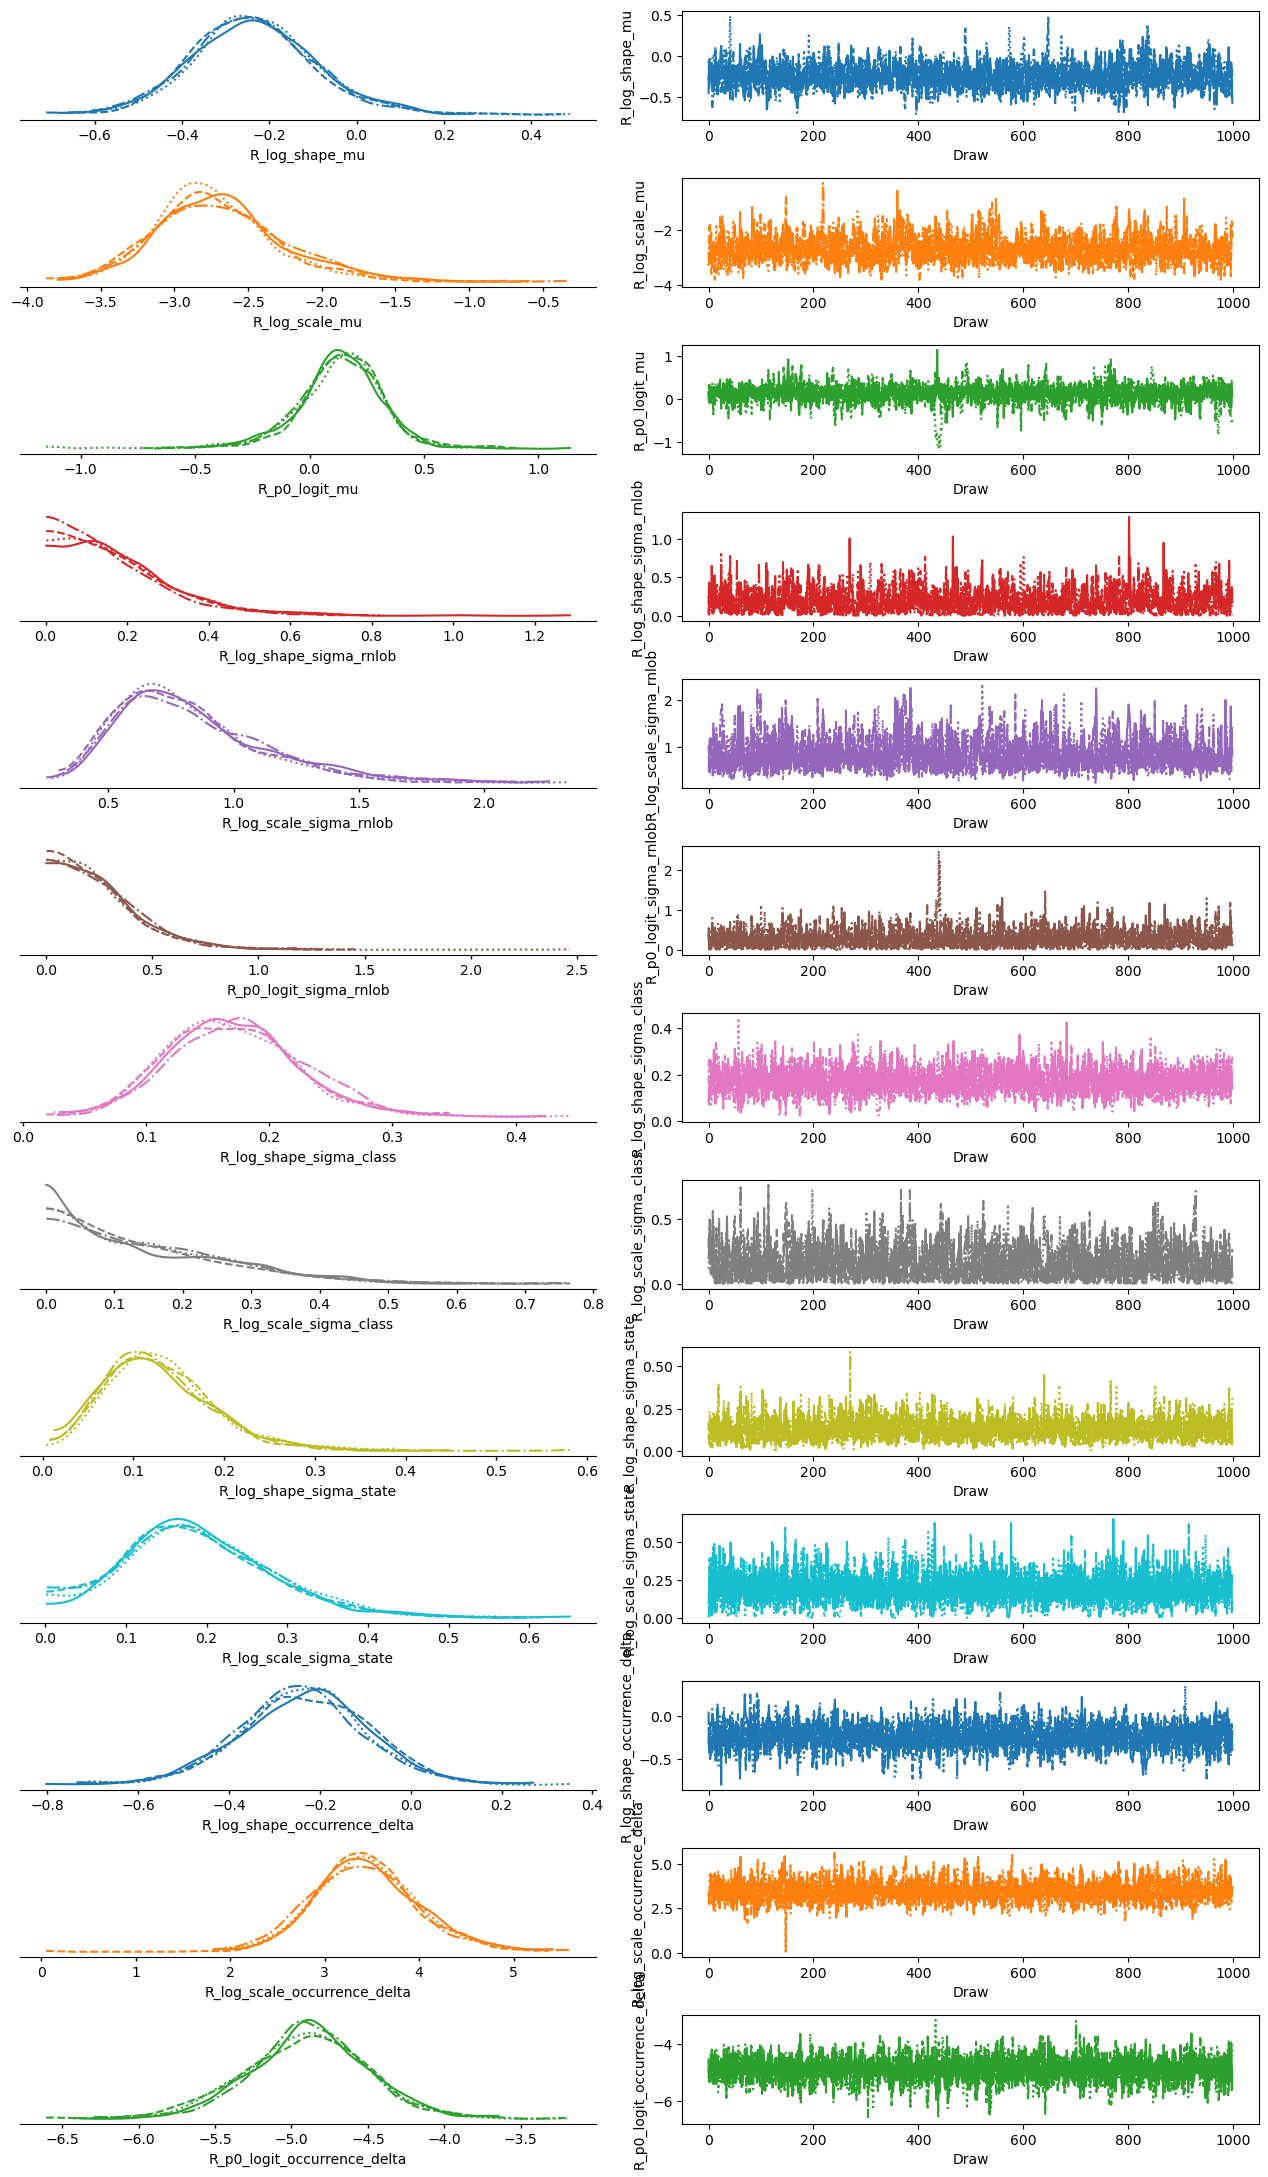

In [15]:
az.plot_trace_dist(
    iso_r_idata,
    var_names=[
        'R_log_shape_mu',
        'R_log_scale_mu',
        'R_p0_logit_mu',
        'R_log_shape_sigma_rnlob',
        'R_log_scale_sigma_rnlob',
        'R_p0_logit_sigma_rnlob',
        'R_log_shape_sigma_class',
        'R_log_scale_sigma_class',
        'R_log_shape_sigma_state',
        'R_log_scale_sigma_state',
        'R_log_shape_occurrence_delta',
        'R_log_scale_occurrence_delta',
        'R_p0_logit_occurrence_delta'
    ]
)
plt.tight_layout()

<Axes: ylabel='Frequency'>

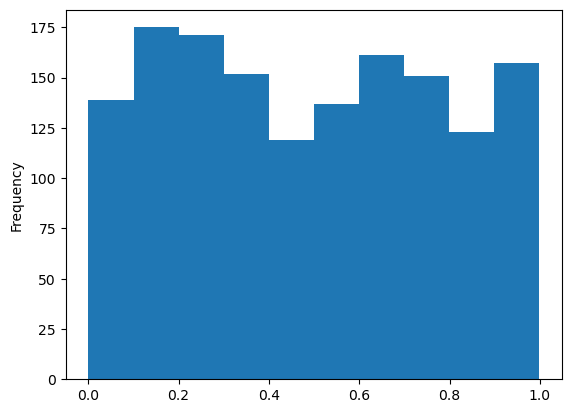

In [16]:
pit_values = pd.Series(az.loo_pit(iso_r_idata)['R_post_pred'].values, index=claims['num_claim'], name='pit')
pit_values.plot(kind='hist')

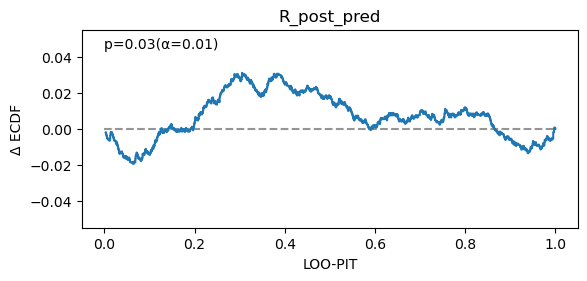

In [17]:
az.plot_loo_pit(iso_r_idata)

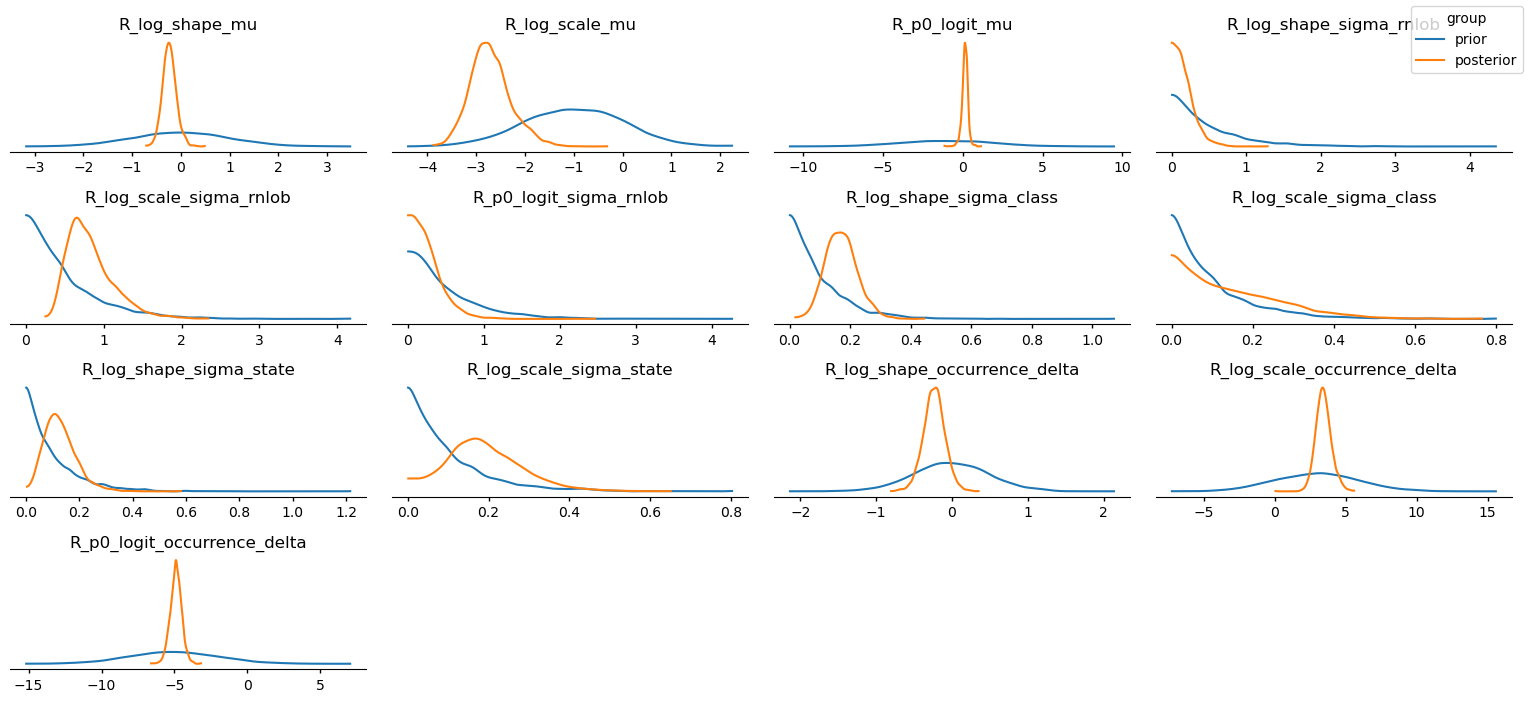

In [18]:
az.plot_prior_posterior(
    iso_r_idata,
    var_names=[
        'R_log_shape_mu',
        'R_log_scale_mu',
        'R_p0_logit_mu',
        'R_log_shape_sigma_rnlob',
        'R_log_scale_sigma_rnlob',
        'R_p0_logit_sigma_rnlob',
        'R_log_shape_sigma_class',
        'R_log_scale_sigma_class',
        'R_log_shape_sigma_state',
        'R_log_scale_sigma_state',
        'R_log_shape_occurrence_delta',
        'R_log_scale_occurrence_delta',
        'R_p0_logit_occurrence_delta'
    ]
)
plt.tight_layout()

### $\theta_R$, % of Claims Reported

count    12436.000000
mean         0.787228
std          0.218454
min          0.121728
25%          0.574951
50%          0.885951
75%          0.998182
max          1.000000
Name: theta_R, dtype: float64

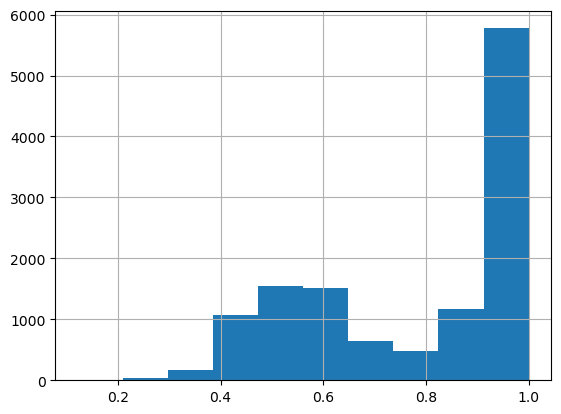

In [19]:
percent_claims_reported = pd.Series(
    posterior_r.stan_variable('theta_R_posterior').mean(axis=0),
    index=frequency_data.index,
    name='theta_R'
)
percent_claims_reported.hist()
percent_claims_reported.describe()

### $C$, Claim Frequency

In [20]:
freq_cc = cmdstanpy.CmdStanModel(stan_file='frequency__counts_C__cross_classified.stan')

11:01:33 - cmdstanpy - INFO - compiling stan file C:\Users\RYANKA~1\AGGREG~1\frequency__counts_C__cross_classified.stan to exe file C:\Users\RyanKarel\Aggregate Loss Cost Modeling\frequency__counts_C__cross_classified.exe
11:08:11 - cmdstanpy - INFO - compiled model executable: C:\Users\RyanKarel\Aggregate Loss Cost Modeling\frequency__counts_C__cross_classified.exe


In [21]:
stan_data['theta_R'] = percent_claims_reported

noise_scale = 10
mcmc_inits = {
    'log_lambda_0': -5,
    'log_lambda_E': [np.log(0.1)] * E_cols,
    'C_log_phi_mu': 0,
    'C_eta_sigma_class': 0.2,
    'C_eta_sigma_state': 0.2,
    'C_eta_sigma_rnlob': 0.2,
    'C_eta_class_z': np.random.standard_normal(K_class) / noise_scale,
    'C_eta_state_z': np.random.standard_normal(K_state) / noise_scale,
    'C_eta_rnlob_z': np.random.standard_normal(K_rnlob) / noise_scale,
    'C_log_phi_sigma_rnlob': 0.1,
    'C_log_phi_rnlob_z': np.random.standard_normal(K_rnlob) / noise_scale,
}

prior_freq_cc = freq_cc.sample(
    data={**stan_data, 'prior_only': 1},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

posterior_freq_cc = freq_cc.sample(
    data={**stan_data, 'prior_only': 0},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

11:08:14 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

...

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

13:25:10 - cmdstanpy - INFO - CmdStan done processing.
13:25:10 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'frequency__counts_C__cross_classified.stan', line 145, column 8 to column 54)
Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'frequency__counts_C__cross_classified.stan', line 145, column 8 to column 54)
Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'frequency__counts_C__cross_classified.stan', line 145, column 8 to column 54)
	Exception: neg_binomial_2_log_lpmf: Precision parameter[1] is 0, but must be positive finite! (in 'frequency__counts_C__cross_classified.stan', line 145, column 8 to column 54)
Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'frequency__counts_C__cross_classified.stan', line 145, column 8 to column 54)
Consider 

##### Diagnostics

In [22]:
freq_cc_idata = az.from_cmdstanpy(
    posterior=posterior_freq_cc,
    posterior_predictive='C_reported_post_pred',
    prior=prior_freq_cc,
    prior_predictive='C_reported_post_pred',
    observed_data={'C_reported_post_pred': observed_frequency_data},
    log_likelihood={'C_reported_post_pred': 'C_reported_log_lik'},
    dtypes={'C_reported_post_pred': 'int'}
)

c:\Users\RyanKarel\anaconda3\envs\data-env-26-2\Lib\site-packages\arviz_base\io_cmdstanpy.py:383: RuntimeWarning: invalid value encountered in cast
  raw_draws = raw_draws.astype(dtypes.get(item))


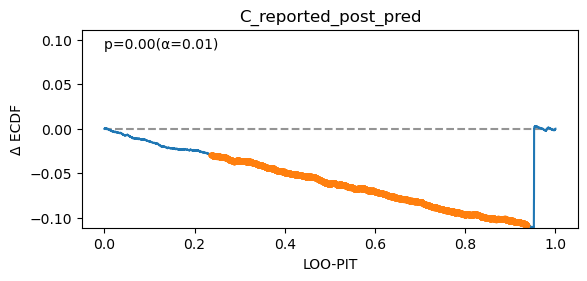

In [23]:
az.plot_loo_pit(freq_cc_idata)

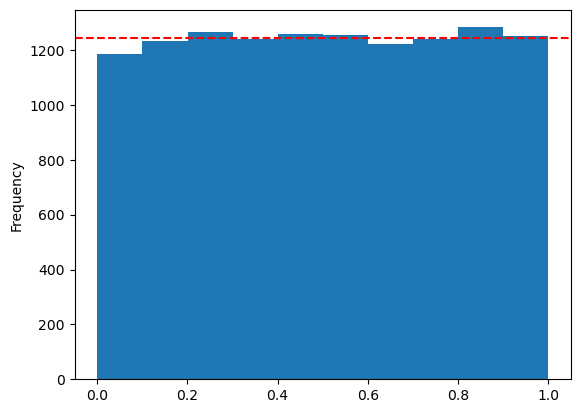

In [24]:
pit_values = pd.Series(az.loo_pit(freq_cc_idata)['C_reported_post_pred'].values, index=frequency_data.index, name='pit')
ax = pit_values.plot(kind='hist')
ax.axhline(len(frequency_data)/10, color='red', ls='--')

In [25]:
az.plot_prior_posterior(freq_cc_idata, var_names=[
    'log_lambda_0',
    'log_lambda_E',
    'C_log_phi_mu',
    'C_eta_sigma_class',
    'C_eta_sigma_state',
    'C_eta_sigma_rnlob',
    'C_log_phi_sigma_rnlob'
])
plt.tight_layout()

MemoryError: Unable to allocate 380. MiB for an array with shape (4000, 12436) and data type float64

In [26]:
posterior_freq_cc.stan_variable('C_reported_post_pred').mean()

np.float64(0.1222745657767771)

In [27]:
observed_frequency_data.mean()

np.float64(0.11941138629784497)

# Severity

## Data

In [7]:
itd_sql = """
with claim_stats as (
    select
        num_claim,
        num_policy,
        c.cd_cause_of_loss,
        c.cd_severity,
        p.cd_product,
        c.cd_occurrence_state,
        lcg.cd_group_name as cd_largest_class_group,
        coalesce(p.amt_occurrence_limit, p.amt_claim_limit) as amt_claim_limit,
        c.dt_claim_report,
        timestamp_settlement as dt_settlement,
        if(cd_claim_status = 'Closed', dt_claim_closed) as dt_claim_closed,
        greatest(
            date_diff(
                'day',
                dt_claim_report,
                coalesce(timestamp_settlement, if(cd_claim_status = 'Closed', dt_claim_closed))
            ) / 365.0,
            0.001
        ) as settlement_lag,
        greatest(
            date_diff(
                'day',
                dt_claim_report, -- making everything relative to report date for consistency
                if(cd_claim_status = 'Closed', dt_claim_closed)
            ) / 365.0,
            0.001
        ) as closure_lag,
        greatest(
            date_diff(
                'day',
                dt_claim_report,
                current_timestamp
            ) / 365.0,
            0.001
        ) as age
    from tbl_claim c
    inner join tbl_policy p using (num_policy)
    left join (select num_claim, timestamp_settlement from tbl_settlement) s using (num_claim)
    left join vw_largest_class_group lcg using (num_policy)
    where
        coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
        and p.cd_product not in ('CP', 'IM') -- non property
        and dt_claim_report < current_timestamp - interval '3' month
),

transactions as (
    select
        num_claim,
        sum(coalesce(amt_paid, 0)) filter (where ind_loss and not ind_recovery) as paid_loss,
        sum(coalesce(amt_incurred, 0)) filter (where ind_loss and not ind_recovery) as incurred_loss,
        sum(coalesce(amt_paid, 0)) filter (where ind_dcc and not ind_recovery) as paid_dcc,
        sum(coalesce(amt_incurred, 0)) filter (where ind_dcc and not ind_recovery) as incurred_dcc,
        sum(coalesce(amt_incurred, 0)) filter (where ind_recovery) as recoveries
    from (
        select
            *,
            cd_financial_type = 'Loss' as ind_loss,
            cd_financial_type = 'DCC' as ind_dcc,
            cd_claim_transaction_type like 'Recov%' as ind_recovery
        from tbl_claim_transaction
    ) t
    inner join claim_stats c using (num_claim)
    where cd_financial_type != 'AO'
    group by 1
)

select *
from claim_stats c
inner join transactions t using (num_claim)
"""

In [8]:
itd_data = query_athena(
    sql=itd_sql,
    boto3_session=boto3_session
)
itd_data.set_index('num_claim', inplace=True)
itd_data = itd_data.loc[itd_data['incurred_loss'] > 100]

scale = 1000

itd_data['cd_cause_of_loss'] = factor_lump(itd_data['cd_cause_of_loss'], options=cd_cause_of_loss)
itd_data['cd_largest_class_group'] = factor_lump(itd_data['cd_largest_class_group'], options=cd_class_groups)
itd_data['cd_occurrence_state'] = factor_lump(itd_data['cd_occurrence_state'], options=cd_states)
itd_data['incurred_loss'] = itd_data['incurred_loss'] / scale
itd_data['incurred_dcc'] = itd_data['incurred_dcc'].fillna(0) / scale
itd_data

,num_policy,cd_cause_of_loss,cd_severity,cd_product,cd_occurrence_state,cd_largest_class_group,amt_claim_limit,dt_claim_report,dt_settlement,dt_claim_closed,settlement_lag,closure_lag,age,paid_loss,incurred_loss,paid_dcc,incurred_dcc,recoveries
num_claim,,,,,,,,,,,,,,,,,,
RN-9-0002109,RN-7-0509166,Bodily Injury,2,GC,FL,Hotels and Motels,1000000.0000,2025-05-13,None,None,NaN,NaN,1.331507,0.00,25.00000,2810.0,25.000,NaN
RN-9-0002127,RN-7-0500548-01,Premises/Slip/Trip/ fall,3,GC,FL,Townhouses,1000000.0000,2025-05-15,2026-02-04,2026-02-04,0.726027,0.726027,1.326027,15182.68,15.18268,NaN,0.000,NaN
RN-9-0002239,RN-7-0325515-01,Water damage PD incl sprinkler leakage,2,GC,FL,Condominiums,1000000.0000,2025-06-16,2025-10-02,2025-12-04,0.295890,0.468493,1.238356,20000.00,20.00000,7532.0,7.532,NaN
RN-9-0002244,RN-7-0501518-01,Line Strike,3,CN,FL,Digging,1000000.0000,2025-06-16,2025-10-07,2025-10-14,0.309589,0.328767,1.238356,5997.02,5.99702,NaN,0.000,NaN
RN-9-0002294,RN-7-0510505,Assault and battery/other than sexual or firearm,3,GC,FL,Condominiums,1000000.0000,2025-06-30,2026-06-06,2026-06-06,0.934247,0.934247,1.200000,17500.00,17.50000,NaN,0.000,-5000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RN-9-0001859,RN-7-0501180,Line Strike,3,CN,FL,Digging,1000000.0000,2025-03-07,2025-07-18,2025-07-18,0.364384,0.364384,1.515068,2250.00,2.25000,NaN,0.000,-2250.0
RN-9-0001881,RN-7-0326823-01,Other,2,PE,GA,Police Professional,1000000.0000,2025-03-13,None,None,NaN,NaN,1.498630,0.00,25.00000,0.0,10.000,NaN
RN-9-0001988,RN-7-0500550,Assault and battery/other than sexual or firearm,1,GC,CO,Apartments,1000000.0000,2025-04-14,2025-07-31,2025-11-10,0.295890,0.575342,1.410959,100000.00,100.00000,NaN,0.000,NaN


In [9]:
# grouping variables
product_groups = {
    'Professional Ex-AH': (
        'PE',
        'ML',
        'PL'
     ),
    'Allied Health': ('AH',),
    'Products Liability': ('PR',),
    'Premises Liability': ('GC', 'SGC'),
    'Contractors Casualty': ('CN', 'SCN')
}
def group_to_idx(grouping: dict[str, tuple]):
    return {
        group: i + 1
        for i, key in enumerate(grouping)
        for group in grouping[key]
    }

product_to_idx = group_to_idx(product_groups)

class_cat = itd_data['cd_largest_class_group'].astype('category')
class_to_idx = {c: i+1 for i, c in enumerate(class_cat.cat.categories)}

state_cat = itd_data['cd_occurrence_state'].astype('category')
state_to_idx = {c: i+1 for i, c in enumerate(state_cat.cat.categories)}

cause_cat = itd_data['cd_cause_of_loss'].astype('category')
cause_to_idx = {c: i+1 for i, c in enumerate(cause_cat.cat.categories)}

itd_data['g_class'] = itd_data['cd_largest_class_group'].map(class_to_idx)
itd_data['g_state'] = itd_data['cd_occurrence_state'].map(state_to_idx)
itd_data['g_rnlob'] = itd_data['cd_product'].map(product_to_idx)
itd_data['g_svrty'] = itd_data['cd_severity'].astype(int)
itd_data['g_cause'] = itd_data['cd_cause_of_loss'].map(cause_to_idx)
itd_stan_data = {
    'N': len(itd_data),
    'R': itd_data['incurred_loss'],
    'D': itd_data['incurred_dcc'],
    'S': itd_data['settlement_lag'].fillna(0),
    'T': itd_data['age'],
    'settled': itd_data['settlement_lag'].apply(pd.notna).astype(int),

    'K_class': itd_data['g_class'].max(),
    'K_state': itd_data['g_state'].max(),
    'K_rnlob': itd_data['g_rnlob'].max(),
    'K_svrty': itd_data['g_svrty'].max(),
    'K_cause': itd_data['g_cause'].max(),
    'g_class': itd_data['g_class'],
    'g_state': itd_data['g_state'],
    'g_rnlob': itd_data['g_rnlob'],
    'g_svrty': itd_data['g_svrty'],
    'g_cause': itd_data['g_cause']
}

N_unsettled = itd_data['settlement_lag'].apply(pd.isna).sum()

## Model Training

### $X_{Loss}$, Indemnity Severity

In [31]:
indemnity_severity_model = cmdstanpy.CmdStanModel(stan_file='severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced.stan')

In [32]:
mcmc_inits = {
    'S_log_lambda_mu': 0,
    'S_log_lambda_sigma_rnlob': 0.10,
    'S_log_lambda_sigma_svrty': 0.10,
    'X_log_alpha_mu': -1,
    'X_log_beta_mu': -3,
    'X_log_alpha_sigma_class': 0.10,
    'X_log_beta_sigma_class': 0.10,
    'X_log_alpha_sigma_state': 0.10,
    # 'X_log_beta_sigma_state': 0.10,
    'X_log_alpha_sigma_rnlob': 0.10,
    'X_log_beta_sigma_rnlob': 0.10,
    # 'X_log_alpha_sigma_svrty': 0.10,
    'X_log_beta_sigma_svrty': 0.10,
    'X_log_alpha_sigma_cause': 0.10,
    'X_log_beta_sigma_cause': 0.10,
    'g_log_alpha_mu': 0.00,
    'g_log_alpha_sigma_rnlob': 0.10,
    # 'g_log_alpha_sigma_svrty': 0.10,
    'X_log_scale_trend_mu': 0.05,
    'X_log_scale_trend_sigma_rnlob': 0.01,

    'X_log_alpha_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_alpha_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'X_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_alpha_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'X_log_beta_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    # 'X_log_beta_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_beta_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_beta_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_beta_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'S_log_lambda_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'S_log_lambda_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'g_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'g_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_scale_trend_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 100,

    'S_unknown_minus_age': 1 +  np.random.standard_normal(size=N_unsettled) / 10
}
posterior_idemnity = indemnity_severity_model.sample(
    data=itd_stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits,
    adapt_delta=0.98
)

13:46:19 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

13:53:21 - cmdstanpy - INFO - CmdStan done processing.
13:53:21 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Inverse scale parameter[1] is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced.stan', line 319, column 4 to column 40)
	Exception: gamma_lpdf: Inverse scale parameter[1] is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced.stan', line 319, column 4 to column 40)
	Exception: gamma_lpdf: Inverse scale parameter[1] is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced.stan', line 319, column 4 to column 40)
	Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced.stan', line 20, column 8 to column 79) (in 'severity__repo

#### Diagnostics

In [33]:
indemnity_idata = az.from_cmdstanpy(
    posterior=posterior_idemnity,
    posterior_predictive='R_post_pred',
    observed_data={'R_post_pred': itd_data['incurred_loss']},
    log_likelihood={'R_post_pred': 'R_log_lik'},
    dims={
        'X_log_alpha_class_z': ['class'],
        'X_log_alpha_state_z': ['state'],
        'X_log_alpha_rnlob_z': ['rnlob'],
        'X_log_beta_class_z': ['class'],
        'X_log_beta_rnlob_z': ['rnlob'],
        'X_log_beta_svrty_z': ['svrty'],
        'S_log_lambda_rnlob_z': ['rnlob'],
        'S_log_lambda_svrty_z': ['svrty'],
        'g_log_alpha_rnlob_z': ['rnlob'],
        'X_log_scale_trend_rnlob_z': ['rnlob'],
        'R': ['obs_id'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'g_rnlob': ['obs_id'],
        'g_svrty': ['obs_id'],
        'R_post_pred': ['obs_id'],
        'R_log_lik': ['obs_id']
    },
    coords={
        'class': class_cat.cat.categories.tolist(),
        'state': state_cat.cat.categories.tolist(),
        'rnlob': list(product_groups.keys()),
        'svrty': ['1. High', '2. Mid', '3. Low'],
        'cause': cause_cat.cat.categories.tolist(),
        'obs_id': itd_data.index.tolist()
    }
)


In [ ]:
az.plot_trace_dist(
    indemnity_idata,
    var_names=[
        ...
    ]
)
plt.tight_layout()

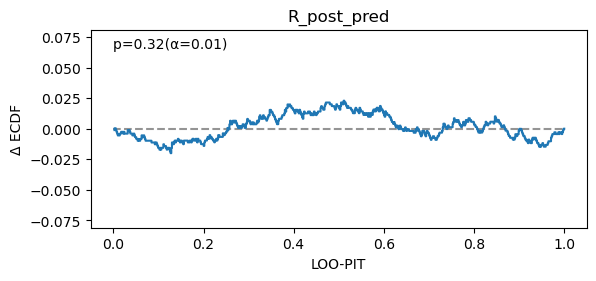

In [34]:
az.plot_loo_pit(indemnity_idata)

<Axes: ylabel='Frequency'>

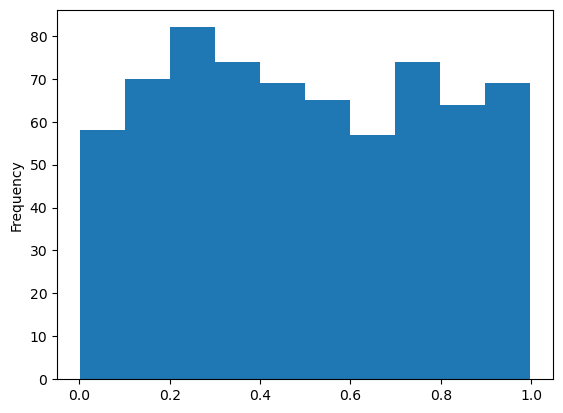

In [35]:
pit_values = pd.Series(az.loo_pit(indemnity_idata)['R_post_pred'].values, index=itd_data.index, name='pit')
pit_values.plot(kind='hist')

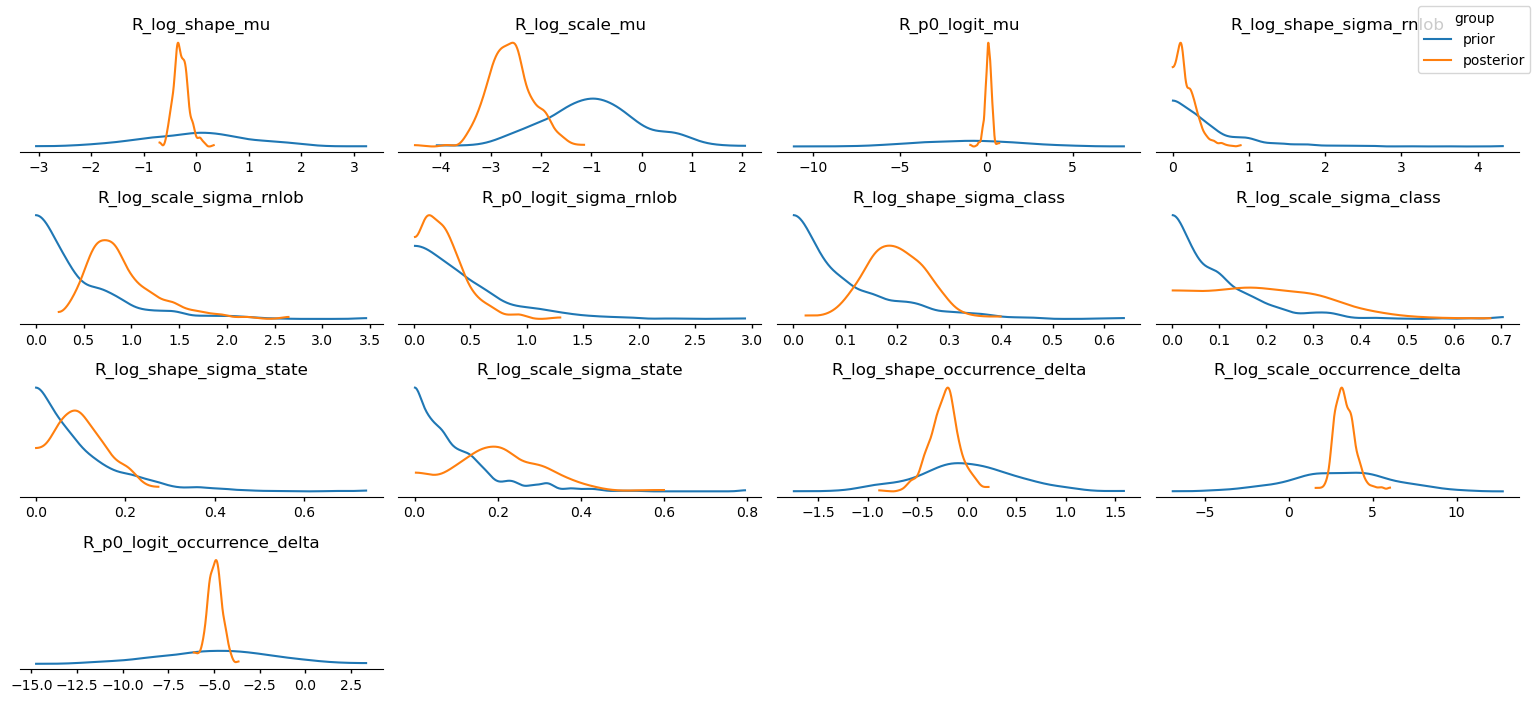

In [ ]:
az.plot_prior_posterior(
    indemnity_idata,
    var_names=[
        ...
    ]
)
plt.tight_layout()

### $X_{DCC}$, DCC Severity

In [ ]:
dcc_severity_model = cmdstanpy.CmdStanModel(stan_file='severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced_hurdled.stan')

In [38]:
mcmc_inits = {
    'S_log_lambda_mu': 0,
    'S_log_lambda_sigma_rnlob': 0.10,
    'S_log_lambda_sigma_svrty': 0.10,
    'X_log_alpha_mu': -1,
    'X_log_beta_mu': -3,
    'X_log_alpha_sigma_class': 0.10,
    'X_log_beta_sigma_class': 0.10,
    'X_log_alpha_sigma_state': 0.10,
    # 'X_log_beta_sigma_state': 0.10,
    'X_log_alpha_sigma_rnlob': 0.10,
    'X_log_beta_sigma_rnlob': 0.10,
    # 'X_log_alpha_sigma_svrty': 0.10,
    'X_log_beta_sigma_svrty': 0.10,
    'X_log_alpha_sigma_cause': 0.10,
    'X_log_beta_sigma_cause': 0.10,
    'g_log_alpha_mu': 0.00,
    'g_log_alpha_sigma_rnlob': 0.10,
    # 'g_log_alpha_sigma_svrty': 0.10,
    'X_log_scale_trend_mu': 0.05,
    'X_log_scale_trend_sigma_rnlob': 0.01,

    'X_log_alpha_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    'X_log_alpha_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'X_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_alpha_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'X_log_beta_class_z': np.random.standard_normal(size=itd_stan_data['K_class']) / 10,
    # 'X_log_beta_state_z': np.random.standard_normal(size=itd_stan_data['K_state']) / 10,
    'X_log_beta_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'X_log_beta_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_beta_cause_z': np.random.standard_normal(size=itd_stan_data['K_cause']) / 10,
    'S_log_lambda_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    'S_log_lambda_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'g_log_alpha_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 10,
    # 'g_log_alpha_svrty_z': np.random.standard_normal(size=itd_stan_data['K_svrty']) / 10,
    'X_log_scale_trend_rnlob_z': np.random.standard_normal(size=itd_stan_data['K_rnlob']) / 100,

    'S_unknown_minus_age': 1 +  np.random.standard_normal(size=N_unsettled) / 10
}
posterior_dcc = dcc_severity_model.sample(
    data={**itd_stan_data, 'R': itd_data['incurred_dcc']},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    output_dir=r'C:\Users\RyanKarel\stan_outputs', # only sometimes necessary
    inits=mcmc_inits,
    adapt_delta=0.99
)

13:55:32 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

14:02:48 - cmdstanpy - INFO - CmdStan done processing.
14:02:48 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: gamma_lpdf: Inverse scale parameter is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced_hurdled.stan', line 32, column 16 to column 89) (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced_hurdled.stan', line 359, column 4 to column 59)
	Exception: Exception: gamma_lpdf: Inverse scale parameter is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced_hurdled.stan', line 32, column 16 to column 89) (in 'severity__reported_R__settlement_S__development_g__cross_classified_trended_reduced_hurdled.stan', line 359, column 4 to column 59)
	Exception: Exception: weibull_lcdf: Shape parameter is 0, but must be positive finite! (in 'severity__reported_R__settlement_S__development_g__

14:02:53 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 1 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


#### Diagnostics

In [39]:
dcc_idata = az.from_cmdstanpy(
    posterior=posterior_dcc,
    posterior_predictive='R_post_pred',
    observed_data={'R_post_pred': itd_data['incurred_dcc']},
    log_likelihood={'R_post_pred': 'R_log_lik'},
    dims={
        'X_log_alpha_class_z': ['class'],
        'X_log_alpha_state_z': ['state'],
        'X_log_alpha_rnlob_z': ['rnlob'],
        'X_log_beta_class_z': ['class'],
        'X_log_beta_rnlob_z': ['rnlob'],
        'X_log_beta_svrty_z': ['svrty'],
        'S_log_lambda_rnlob_z': ['rnlob'],
        'S_log_lambda_svrty_z': ['svrty'],
        'g_log_alpha_rnlob_z': ['rnlob'],
        'X_log_scale_trend_rnlob_z': ['rnlob'],
        'R': ['obs_id'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'g_rnlob': ['obs_id'],
        'g_svrty': ['obs_id'],
        'R_post_pred': ['obs_id'],
        'R_log_lik': ['obs_id']
    },
    coords={
        'class': class_cat.cat.categories.tolist(),
        'state': state_cat.cat.categories.tolist(),
        'rnlob': list(product_groups.keys()),
        'svrty': ['1. High', '2. Mid', '3. Low'],
        'cause': cause_cat.cat.categories.tolist(),
        'obs_id': itd_data.index.tolist()
    }
)


In [ ]:
az.plot_trace_dist(
    dcc_idata,
    var_names=[
        ...
    ]
)
plt.tight_layout()

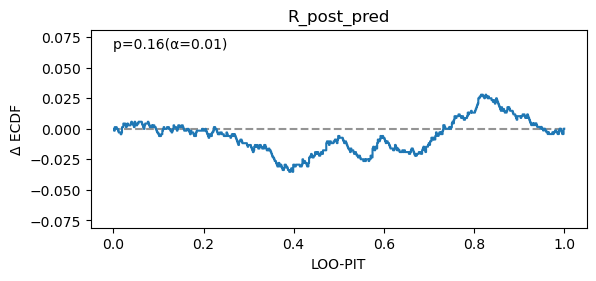

In [40]:
az.plot_loo_pit(dcc_idata)

<Axes: ylabel='Frequency'>

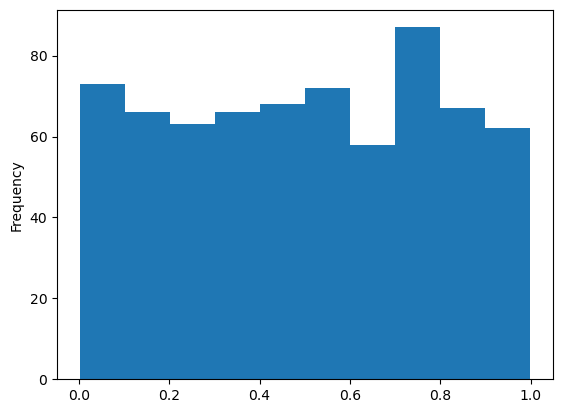

In [41]:
pit_values = pd.Series(az.loo_pit(dcc_idata)['R_post_pred'].values, index=itd_data.index, name='pit')
pit_values.plot(kind='hist')

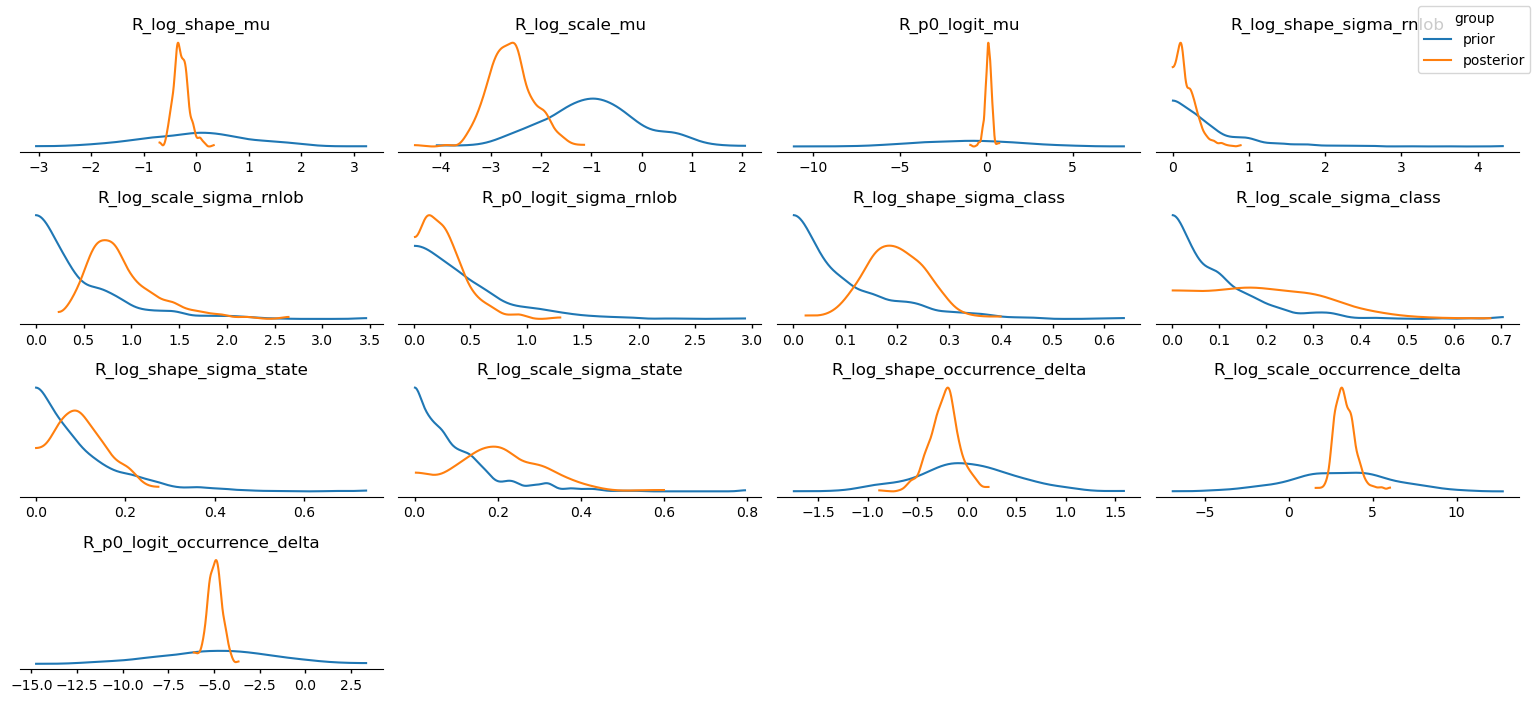

In [ ]:
az.plot_prior_posterior(
    dcc_idata,
    var_names=[
        ...
    ]
)
plt.tight_layout()

# Combine Models

## Claim Categorization

Can use same data as severity model. We probably need to model correlation between the cause of loss and severity code.

In [10]:
group_frequency = itd_data[['cd_cause_of_loss', 'cd_severity']].pivot_table(index='cd_cause_of_loss', columns='cd_severity', aggfunc='size').fillna(0).astype(int)
group_frequency.sort_index(key=lambda idx: group_frequency.sum(axis=1), ascending=False).head(15)

cd_severity,1,2,3
cd_cause_of_loss,,,
Premises/Slip/Trip/ fall,16,88,45
Water damage PD incl sprinkler leakage,3,32,69
Other,20,30,53
Line Strike,0,7,64
Construction defect/ defective workmanship,3,14,34
Bodily Injury,7,22,16
Failure to provide IEP,0,5,16
Fall - not in bathroom/shower,6,9,1
Premises/injury by object,1,4,10


In [11]:
categorization_correl = cmdstanpy.CmdStanModel(stan_file='connector__claim_categorization_k__correlated.stan')
cat_correl_posterior = categorization_correl.sample(
    {**itd_stan_data, 'correlation_regularization_strength': 1},
    n_chains = 4,
    iter_warmup = 1000,
    iter_sampling = 1000
)
cat_correl_1_0_idata = az.from_cmdstanpy(
    posterior=cat_correl_posterior,
    posterior_predictive='k_joint_post_pred',
    log_likelihood={'k_joint_post_pred': 'k_joint_log_lik'}
)

11:34:45 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

11:48:13 - cmdstanpy - INFO - CmdStan done processing.
11:48:13 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lkj_corr_cholesky_lpdf: Random variable[34] is 0, but must be positive! (in 'connector__claim_categorization_k__correlated.stan', line 59, column 4 to column 69)
	Exception: lkj_corr_cholesky_lpdf: Random variable[36] is 0, but must be positive! (in 'connector__claim_categorization_k__correlated.stan', line 59, column 4 to column 69)
	Exception: lkj_corr_cholesky_lpdf: Random variable[36] is 0, but must be positive! (in 'connector__claim_categorization_k__correlated.stan', line 59, column 4 to column 69)
	Exception: lkj_corr_cholesky_lpdf: Random variable[31] is 0, but must be positive! (in 'connector__claim_categorization_k__correlated.stan', line 59, column 4 to column 69)
	Exception: lkj_corr_cholesky_lpdf: Random variable[35] is 0, but must be positive! (in 'connector__claim_categorization_k__correlated.stan', line 59, column 4 to column 69)
	Exception

## Model Sequencing